In [1]:
import numpy as np
import networkx as nx
from scipy.special import betaln
from itertools import combinations
import yaml
from utils import *

with open("cfg.yml", "r") as f:
    cfg = yaml.safe_load(f)
with open("cfg.yml", "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f) or {}

for key, value in CFG.items():
    globals()[key] = value

NET_SIZES = cfg["net_size"]                         # 10, 25, 50, 100, 200
TOPOLOGIES = cfg["topology"]                        # "cycle", "wheel", ["clustered", "scale_free", "random"]
THEORIES = cfg["theories"]                          # [0.82, 0.81, 0.80, 0.79, 0.78], [0.9, 0.85, 0.8, 0.75, 0.7], [0.82, 0.81, 0.80, 0.70, 0.50] 
TOP_PRIORS_STRENGTH = cfg["top_priors_strength"]    # 4, 40, 400, 4000
DENSITIES = cfg["density"]                          # 0 to 1, step 0.1
STEPS = 100
N_RUNS = 5
SEED = 1

RNG = np.random.default_rng(SEED)

In [3]:
'''
Choose your graph here with differend random seeds
'''

import pickle

with open("graphs_42.pkl", "rb") as f:
    graphs_42 = pickle.load(f)
    graphs_42 = restructure(graphs_42)
# with open("graphs_666.pkl", "rb") as f:
#     graphs_666 = pickle.load(f)
#     graphs_666 = restructure(graphs_666)
# with open("graphs_100.pkl", "rb") as f:
#     graphs_100 = pickle.load(f)
#     graphs_100 = restructure(graphs_100)
# with open("graphs_1.pkl", "rb") as f:
#     graphs_1 = pickle.load(f)
#     graphs_1 = restructure(graphs_1)
# with open("graphs_808.pkl", "rb") as f:
#     graphs_808 = pickle.load(f)
#     graphs_808 = restructure(graphs_808)

graphs = graphs_42
debug_graphs(graphs)

All clean.


[]

## Dropdown for understanding the data structure

=================== Let's have a look at the graphs ===================


 ======= 'Graphs' is a dictionary with 1920 different graphs:                 ======= 
 ======= 5 SIZES X 33 TOPOLOGIES-DENSITIES X 3 THEORY_SETS X 4 PRIOR_REGIMENS =======

 == Each graph has N nodes where each of the nodes has the following properties: == 
 == (2 Alpha_Beta + 1 EV) X 5 Theories                                           ==


=================== Let's open an example graph ===================


We will consider the graph with 10 nodes, scale-free topology with density 0.75, theory set (0.82, 0.81, 0.80, 0.79, 0.78) and top_prior_strength of 400
Plot below shows the graph structure, with nodes colored by their EV for the first theory (0.82)


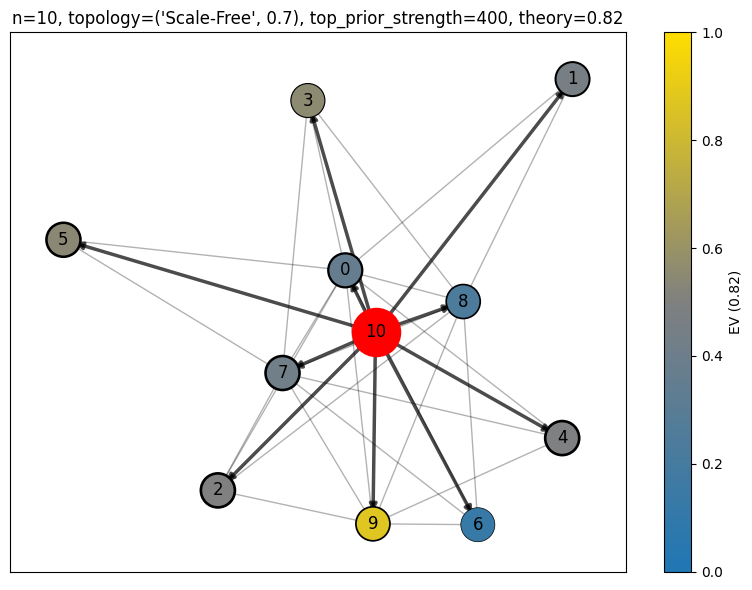

========== What are we seeing here? ==========


-- Nodes are colored by their EV for the first theory (0.82) --
-- Node linewidth is set based on the node's certainty (in log scale)
-- Hub node is directed, will always draw the second-to-best theory (no priors) and is larger & red
===== Let's look into a couple of nodes from this graph =====


-- We will look at node 6 and node 2
-- Specifically, we will look at the betas/EV for the first theory (0.82)
== Node 6
-- Alpha/Beta:  [22.19028804021996, 159.61409340226535] 
-- EV:  0.12205584851231963 
-- Certainty (alpha + beta):  181.80438144248532
== Node 2
-- Alpha/Beta:  [347.94241206562316, 351.2869724120413] 
-- EV:  0.49760839545600866 
-- Certainty (alpha + beta):  699.2293844776644
=================== Each of this graph will be used to run a simulation ===================


In [17]:
print("=================== Let's have a look at the graphs ===================")
print()
print()
print(" ======= 'Graphs' is a dictionary with 1920 different graphs:                 ======= \n ======= 5 SIZES X 33 TOPOLOGIES-DENSITIES X 3 THEORY_SETS X 4 PRIOR_REGIMENS =======")
print()
print(" == Each graph has N nodes where each of the nodes has the following properties: == \n == (2 Alpha_Beta + 1 EV) X 5 Theories                                           ==")
print()
print()

print("=================== Let's open an example graph ===================")
print()
print()
print("We will consider the graph with 10 nodes, scale-free topology with density 0.75, theory set (0.82, 0.81, 0.80, 0.79, 0.78) and top_prior_strength of 400")
print("Plot below shows the graph structure, with nodes colored by their EV for the first theory (0.82)")

plot_graph(graphs, size=10, topology='Scale-Free', density=0.7, 
           top_prior_strength=400, theory_set=(0.82, 0.81, 0.8, 0.79, 0.78), theory=0.82,
           max_certainty=8000)

print("========== What are we seeing here? ==========")
print()
print()
print("-- Nodes are colored by their EV for the first theory (0.82) --")
print("-- Node linewidth is set based on the node's certainty (in log scale)")
print("-- Hub node is directed, will always draw the second-to-best theory (no priors) and is larger & red")

print("===== Let's look into a couple of nodes from this graph =====")
print()
print()
print("-- We will look at node 6 and node 2")
print("-- Specifically, we will look at the betas/EV for the first theory (0.82)")
node_data_6 = graphs[10][('Scale-Free', 0.7)][400][(0.82, 0.81, 0.8, 0.79, 0.78)].nodes[6][0.82]
alpha_6 = node_data_6[0]
beta_6 = node_data_6[1]
ev_6 = alpha_6 / (alpha_6 + beta_6)
node_data_2 = graphs[10][('Scale-Free', 0.7)][400][(0.82, 0.81, 0.8, 0.79, 0.78)].nodes[2][0.82]
alpha_2 = node_data_2[0]
beta_2 = node_data_2[1]
ev_2 = alpha_2 / (alpha_2 + beta_2)
print("== Node 6")
print("-- Alpha/Beta: ", node_data_6, "\n-- EV: ", ev_6, "\n-- Certainty (alpha + beta): ", alpha_6 + beta_6)
print("== Node 2")
print("-- Alpha/Beta: ", node_data_2, "\n-- EV: ", ev_2, "\n-- Certainty (alpha + beta): ", alpha_2 + beta_2)

print("=================== Each of this graph will be used to run a simulation ===================")

## Simulate

In [ ]:
''' 
Here I am setting some boilerplate functions for metrics as suggested by Claude. 
TODO: This cell will be filled in with more functions for metrics as I implement them.
'''

'''
def beta_variance(alpha: float, beta: float) -> float:
    """Variance of Beta(alpha, beta)."""
    s = alpha + beta
    return (alpha * beta) / (s**2 * (s + 1))
 
from scipy.stats import beta as beta_dist

def beta_entropy(alpha: float, beta: float) -> float:
    """Differential entropy of Beta(alpha, beta)."""
    return beta_dist.entropy(alpha, beta)
 
def kl_beta(a1, b1, a2, b2) -> float:
    """KL divergence KL(Beta(a1,b1) || Beta(a2,b2))."""
    from scipy.special import digamma
    s1, s2 = a1 + b1, a2 + b2
    return (betaln(a2, b2) - betaln(a1, b1)
            + (a1 - a2) * digamma(a1)
            + (b1 - b2) * digamma(b1)
            + (s2 - s1) * digamma(s1))
 
def mean_pairwise_kl(params: np.ndarray) -> float:
    """Average pairwise KL divergence across all node pairs (symmetrised)."""
    n = len(params)
    if n < 2:
        return 0.0
    total, count = 0.0, 0
    for i, j in combinations(range(n), 2):
        a1, b1 = params[i]
        a2, b2 = params[j]
        kl_sym = 0.5 * (kl_beta(a1, b1, a2, b2) + kl_beta(a2, b2, a1, b1))
        total += kl_sym
        count += 1
    return total / count
'''

In [ ]:
import copy

def compute_metrics(history: list[np.ndarray]) -> dict:
    """Return time-series of mean variance, mean KL, and belief mean std."""
    mean_vars, mean_kls, belief_stds = [], [], []
    for params in history:
        variances = [beta_variance(p[0], p[1]) for p in params]
        mean_vars.append(np.mean(variances))
        mean_kls.append(mean_pairwise_kl(params))
        means = params[:, 0] / params.sum(axis=1)
        belief_stds.append(np.std(means))
    return {
        "mean_variance": np.array(mean_vars),
        "mean_kl":       np.array(mean_kls),
        "belief_std":    np.array(belief_stds),
    }


def simulate(graph: nx.Graph, steps: int = 100):
    
    params = dict(graph.nodes(data=True))
    history = [copy.deepcopy(params)]                   # Start history tracking
    nodes = list(graph.nodes())                 # Get nodes
 
    for _ in range(steps):
        new_params = copy.deepcopy(params)
        
        # ========== TODO: Do some stuff ========== #

        params = new_params
        history.append(copy.deepcopy(params))
 
    return history

# Example usage for one single run
history = simulate(graphs_42[10]["Cycle"], steps=STEPS)

metrics = compute_metrics(history)

KeyError: 'cycle'